# Lab: DBSCAN and HDBSCAN

*In this lab, we will apply density-based clustering algorithms (DBSCAN and HDBSCAN) to museum locations across Canada to help the government determine optimal regional groupings for administrative oversight.*

---

> ### 📝 1. Business Understanding Report (Summary)
> * **Business Context:** Statistics Canada (StatCan) maintains the Open Database of Cultural and Art Facilities (ODCAF), which contains comprehensive information about cultural and art institutions across the country. The Government of Canada is seeking to optimize its administrative structure for museum oversight by assigning regional principals (administrators) to geographically clustered museums.
> * **Business Problem:** The government needs to determine the optimal number of regional clusters for museums across Canada to:
>   1. Assign the appropriate number of regional principals (one principal per cluster)
>   2. Minimize travel and administrative overhead by grouping geographically proximate museums
>   3. Ensure efficient communication and resource sharing between neighboring institutions
>   4. Balance cluster sizes to distribute administrative workload fairly across principals
> * **Project Goals:**
>   1. Discover natural geographic groupings of museums based on spatial proximity
>   2. Recommend an optimal number of regional clusters (and thus regional principals) based on clustering results
>   3. Identify isolated museums that may require special administrative considerations
> * **Success Criteria:**
>   - Clear, interpretable geographic clusters visible on a map of Canada
>   - Reasonable cluster sizes that support equitable distribution of administrative responsibility
>   - Identification of geographic outliers or isolated museums
>   - Evidence-based recommendation on the number of regional principals needed

---

> ### 📝 2. Analytic Approach Report (Summary)
> * **Problem Type:** Unsupervised Learning - Spatial Clustering, with focus on discovering natural geographic groupings based on proximity rather than pre-specifying the number of clusters.
> * **Why Density-Based Clustering?** Unlike K-Means (which requires specifying k clusters in advance and assumes spherical clusters), density-based clustering:
>   - Discovers clusters of arbitrary shapes, ideal for geographic data with irregular distributions
>   - Automatically determines the number of clusters without prior assumptions
>   - Identifies isolated museums (noise points) that may need special handling
>   - Handles varying densities across regions (e.g., densely packed museums in urban areas vs. sparse rural areas)
> * **Algorithms to Compare:**
>   1. **DBSCAN (Density-Based Spatial Clustering of Applications with Noise):**
>       - Core parameters: `eps` (neighborhood radius in degrees) and `min_samples` (minimum museums to form a cluster)
>       - Strength: Simple, interpretable, good for uniform density
>       - Limitation: Struggles with varying densities (may over-connect nearby clusters or fragment sparse regions)
>   2. **HDBSCAN (Hierarchical DBSCAN):**
>       - Core parameter: `min_cluster_size` (minimum museums per cluster)
>       - Strength: Handles varying densities naturally, fewer parameters to tune
>       - Advantage: Better suited for geographic data with mixed urban/rural patterns
> * **Evaluation Metrics:**
>   - **Number of clusters discovered** to inform optimal number of regional principals
>   - **Cluster size distribution** to assess fairness of administrative workload
>   - **Number of noise points** to identify isolated museums requiring special considerations
>   - **Visual inspection on map** to assess geographic sensibility of clusters
>   - **Comparison DBSCAN vs HDBSCAN** to determine which algorithm provides more actionable insights
> * **Deliverable:** Recommendation on optimal number of regional clusters (and thus regional principals) with supporting geographic visualization and cluster analysis

---

> ### 📝 3. Data Requirements Report (Summary)
> * **Museums dataset (ODCAF):** https://www.statcan.gc.ca/en/lode/databases/odcaf (CSV with facility names, types, and coordinates)
> * **License:** Open Government License - Canada
> * **Dataset Overview:**
>   - Multiple facility types; we filter to **museums only**
>   - Each record includes facility name, type, latitude, longitude
> * **Features to Use:**
>   - **Latitude** (±90°) and **Longitude** (0–360°) are sufficient for geographic proximity and clustering
>   - **Index** for reference; other attributes not needed for clustering
> * **Data Quality Considerations:**
>   - Missing values represented as `'..'`
>   - Coordinates loaded as strings → convert to floats
>   - Remove rows without valid coordinates

---

## Stage 4: Data Collection
As usual, we start with importing the necessary libraries and configuring them.

In [79]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import matplotlib.pyplot as plt

import requests
import zipfile
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import hdbscan

# Configurations
plt.style.use("fivethirtyeight")
sns.set_theme(style="white", palette="colorblind")

### 4.1. Extraction
Now let's download the raw dataset as well as the Canada map for visualization.

In [80]:
raw_data_dir = Path('../data/raw')
raw_data_dir.mkdir(parents=True, exist_ok=True)

# Raw Dataset Download
raw_data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/r-maSj5Yegvw2sJraT15FA/ODCAF-v1-0.csv'
raw_data_path = raw_data_dir / 'ODCAF-v1-0.csv'

if not raw_data_path.exists():
    response = requests.get(raw_data_url, stream=True, timeout=30)
    response.raise_for_status()
    with open(raw_data_path, 'wb') as f:
        f.write(response.content)
    print(f"Downloaded raw data to: {raw_data_path}")
else:
    print(f"Raw data file already exists: {raw_data_path}")

Raw data file already exists: ../data/raw/ODCAF-v1-0.csv


In [81]:
# Canada Map Download
zip_file_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/YcUk-ytgrPkmvZAh5bf7zA/Canada.zip'

zip_file_path = raw_data_dir / 'Canada.zip'
if not zip_file_path.exists():
    response = requests.get(zip_file_url, stream=True, timeout=30)
    response.raise_for_status()
    with open(zip_file_path, 'wb') as f:
        f.write(response.content)
    print(f"Downloaded Canada map zip to: {zip_file_path}")
    
    # Unzip the file
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(raw_data_dir)
    print(f"Extracted Canada map files to: {raw_data_dir}")
else:
    print(f"Canada map zip file already exists: {zip_file_path}")

Canada map zip file already exists: ../data/raw/Canada.zip


In [82]:
raw_df = pd.read_csv(raw_data_path, encoding = "ISO-8859-1", na_values=['..'])
print(f"Extracted dataset has {raw_df.shape[0]} samples and {raw_df.shape[1]} features, with {raw_df.isnull().values.sum()} missing values out of {raw_df.size}.")
raw_df.head()

Extracted dataset has 7972 samples and 17 features, with 18109 missing values out of 135524.


,Index,Facility_Name,Source_Facility_Type,ODCAF_Facility_Type,Provider,Unit,Street_No,Street_Name,Postal_Code,City,Prov_Terr,Source_Format_Address,CSD_Name,CSDUID,PRUID,Latitude,Longitude
0,1,#Hashtag Gallery,NaN,gallery,toronto,NaN,801,dundas st w,M6J 1V2,toronto,on,801 dundas st w,Toronto,3520005.0,35.0,43.65169472,-79.408033
1,2,'Ksan Historical Village & Museum,historic site-building or park,museum,canadian museums association,NaN,1500,62 hwy,V0J 1Y0,hazelton,bc,1500 hwy 62 hazelton british columbia v0j 1y0 ...,Hazelton,5949022.0,59.0,55.2645508,-127.642812
2,3,'School Days' Museum,community/regional museum,museum,canadian museums association,NaN,427,queen st,E3B 5R6,fredericton,nb,427 queen st fredericton new brunswick e3b 5r6...,Fredericton,1310032.0,13.0,45.963283,-66.641902
3,4,10 Austin Street,built heritage properties,heritage or historic site,moncton,NaN,10,austin st,E1C 1Z6,moncton,nb,10 austin st,Moncton,1307022.0,13.0,46.09247776,-64.780229
4,5,10 Gates Dancing Inc.,arts,miscellaneous,ottawa,NaN,NaN,NaN,NaN,ottawa,on,NaN,Ottawa,3506008.0,35.0,45.40856224,-75.715368


### 4.2. Transformation
It's time to transform the raw dataset into an interim dataset that holds the cleaned and standardized data with only the features specified in the Data Requirements stage.

In [83]:
# Read the raw data
interim_df = raw_df.copy()

In [84]:
# Select museums only
interim_df = interim_df[interim_df['ODCAF_Facility_Type'] == 'museum']

# Only keep the Index, Latitude and Longitude columns  
interim_df = interim_df[['Index', 'Latitude', 'Longitude']]

# Drop rows with missing values
interim_df = interim_df.dropna()

# Convert column names to lower case
interim_df.columns = [col.lower() for col in interim_df.columns]

# Convert latitude to float
interim_df['latitude'] = interim_df['latitude'].str.replace(',', '').astype(float)

In [85]:
# Manually check the minimum and maximum values for all numerical columns for any abnormalities
print("\n--- Min/Max Summary of Numerical Data ---")
display(interim_df.describe().loc[['min', 'max']])


--- Min/Max Summary of Numerical Data ---


,index,latitude,longitude
min,2.0,41.737209,-139.431695
max,9798.0,67.029613,-52.684217


* 📌 Latitude and longitude values are within the expected ranges.

### 4.3. Loading

In [86]:
# Save interim dataframe as a parquet file
interim_data_dir = Path("../data/interim")
interim_data_dir.mkdir(parents=True, exist_ok=True)
interim_data_path = interim_data_dir / "interim_museums_latlong.parquet"
interim_df.to_parquet(interim_data_path, index=False)
print(f"\nInterim data saved to: {interim_data_path}")


Interim data saved to: ../data/interim/interim_museums_latlong.parquet


### 4.4. Verification

In [87]:
# Load the final interim data and verify its contents
try:
    df_verified = pd.read_parquet(interim_data_path)
    print(f"Verification successful. The following DataFrame is ready for analysis with {df_verified.shape[0]} samples and {df_verified.shape[1]} features:")
    display(df_verified.head())
except Exception as e:
    print(f"An error occurred while verifying the interim data: {e}")

Verification successful. The following DataFrame is ready for analysis with 1607 samples and 3 features:


,index,latitude,longitude
0,2,55.264551,-127.642812
1,3,45.963283,-66.641902
2,10,49.176354,-123.112783
3,15,49.261938,-123.151123
4,18,49.889559,-97.235744



---

> ### 📝 4. Data Collection Report (Summary)
> * Canada basemap [GeoTIFF](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/YcUk-ytgrPkmvZAh5bf7zA/Canada.zip) and [ODCAF museums dataset](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/r-maSj5Yegvw2sJraT15FA/ODCAF-v1-0.csv) (CSV) have been extracted and stored in `../data/raw`.
> * The dataset has been filtered to museums (`ODCAF_Facility_Type == 'museum'`), columns other than `Index`, `Latitude`, and `Longitude` has been dropped, missing values has been dropped, column names has been converted to lower case, the `latitude` column has been converted to float (remove commas), `longitude` column was already numeric. Latitude and longitude ranges have been manually validated via min/max check.
> * The transformed data has been saved to Parquet: `../data/interim/interim_museums_latlong.parquet`
> * The DataFrame is ready for analysis with **1,607 samples** and **3 features**.

---

## Stage 5: Data Understanding
Let's plot our coordinates on a map to see how the museums are distributed across Canada.

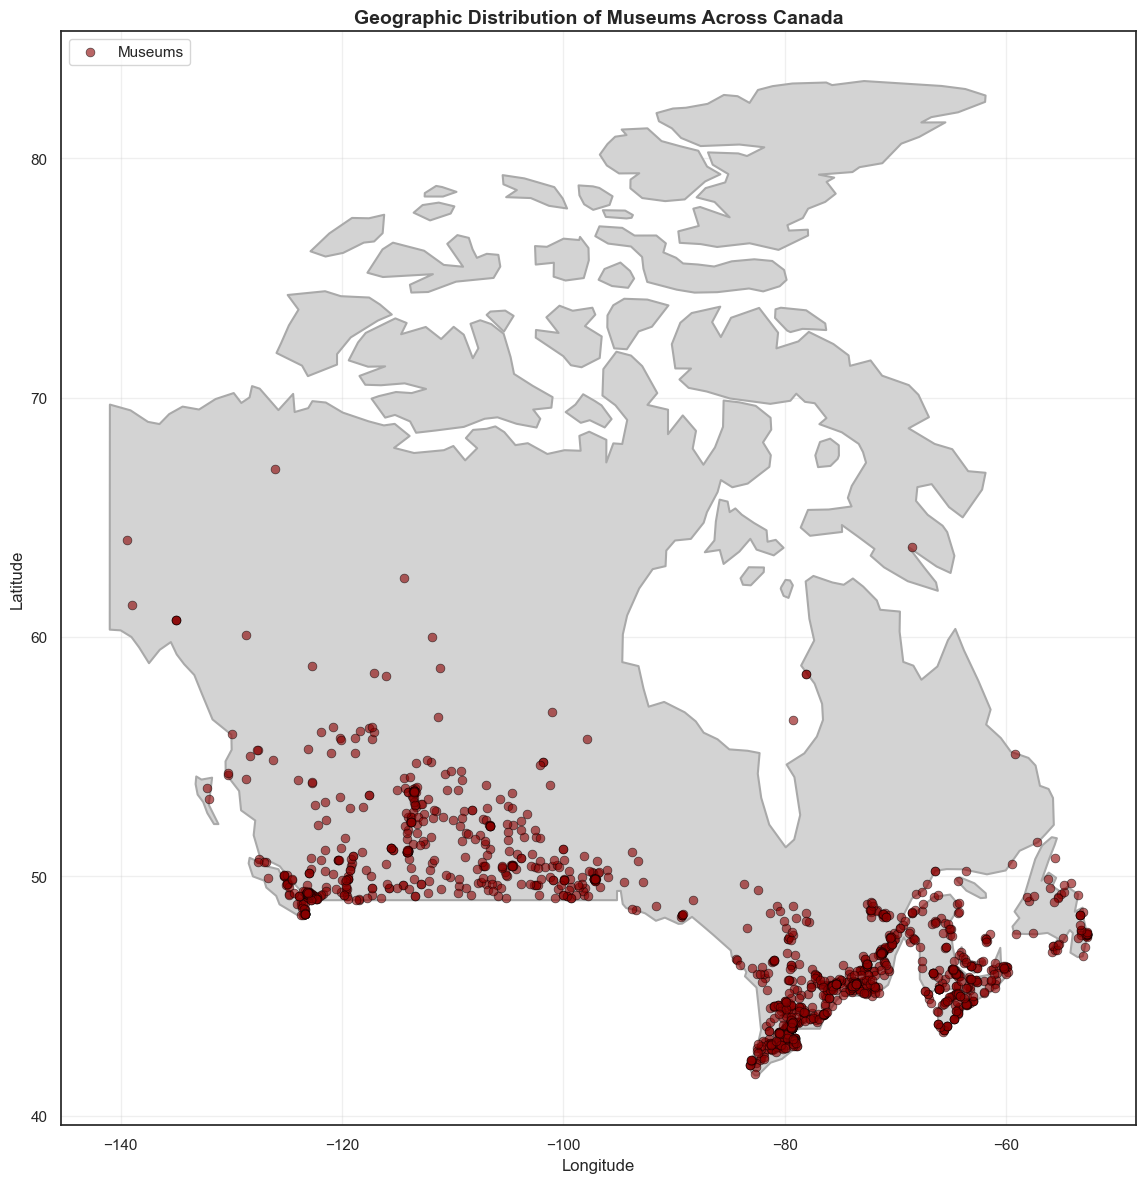

In [88]:
# Download from Natural Earth directly
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)
canada = world[world['NAME'] == 'Canada']

# Create figure with better size and resolution
fig, ax = plt.subplots(figsize=(16, 12))

# Plot Canada boundary
canada.plot(ax=ax, color='lightgray', edgecolor='darkgray', linewidth=1.5)

# Overlay museum points
ax.scatter(df_verified['longitude'], df_verified['latitude'], 
           c='darkred', s=40, alpha=0.6, label='Museums', edgecolors='black', linewidth=0.5)

ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('Geographic Distribution of Museums Across Canada', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---

> ### 📝 5. Data Understanding Report (Summary)
> * **Geographic Distribution Analysis:** The visualization of 1,607 museum locations across Canada reveals a highly **non-uniform spatial distribution** with distinct regional clustering patterns:
>   - Dense urban clusters visible in Southern Ontario, Greater Toronto Area, and British Columbia coastal regions
>   - Moderate concentration in Prairie provinces (Alberta, Manitoba)
>   - Sparse, isolated museums in Northern regions and remote areas
> * **Key Observations Supporting Density-Based Clustering:**
>   1. **Arbitrary Cluster Shapes:** Museums do not form spherical or globular clusters. Instead, they follow geographic and demographic patterns (urban centers, transportation corridors) that create irregular, elongated shapes—K-Means would struggle to capture these naturally occurring patterns.
>   2. **Varying Density Across Regions:** Urban areas (Southern Ontario, Metro Vancouver) show high local density, while Northern Canada exhibits extremely sparse distribution. K-Means assumes uniform density and equal-sized clusters, making it unsuitable for this mixed-density landscape.
>   3. **Natural Noise Points:** Several isolated museums are visible far from major clusters (e.g., remote Northern communities). Density-based algorithms will naturally identify these as noise/outliers, whereas K-Means would force them into nearby clusters, distorting regional groupings.
>   4. **No Pre-specified Cluster Number:** The geographic data naturally suggests 4-6 regional administrative zones based on visual inspection, but density-based clustering allows the algorithm to discover this organically rather than requiring a predetermined *k* value.
> * **Conclusion:** The spatial patterns observed **strongly justify our choice of DBSCAN and HDBSCAN** over K-Means. These density-based algorithms are ideally suited to discover the true geographic groupings present in the data while naturally handling outliers and varying local densities—aligning perfectly with the business goal of creating fair, geographically sensible regional administrative clusters.

---

## Stage 6: Data Preparation
Let's create our feature matrix for the model and scale the features since latitude and longitude have different ranges.

In [89]:
# Create feature matrix (drop 'index' column, keep only latitude and longitude)
X = df_verified[['latitude', 'longitude']].values

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Feature matrix shape: {X_scaled.shape}")
print("\n--- Standardized Features Summary ---")
print(f"Mean of latitude: {X_scaled[:, 0].mean():.6f}")
print(f"Std of latitude: {X_scaled[:, 0].std():.6f}")
print(f"Mean of longitude: {X_scaled[:, 1].mean():.6f}")
print(f"Std of longitude: {X_scaled[:, 1].std():.6f}")
print("\nFirst 5 rows of scaled features:")
print(X_scaled[:5])

Feature matrix shape: (1607, 2)

--- Standardized Features Summary ---
Mean of latitude: 0.000000
Std of latitude: 1.000000
Mean of longitude: -0.000000
Std of longitude: 1.000000

First 5 rows of scaled features:
[[ 2.34451243 -1.90831638]
 [-0.43237299  0.96779781]
 [ 0.52688662 -1.69473134]
 [ 0.55243759 -1.69653902]
 [ 0.73981316 -0.47466236]]



---

> ### 📝 6. Data Preparation Report (Summary)
> * **Feature Matrix Construction:** Extracted latitude and longitude coordinates from the verified dataset, creating a feature matrix of shape (1,607 x 2) containing geographic coordinates for all museums.
> * **Scaling Rationale:** Applied StandardScaler to normalize both latitude and longitude to zero mean and unit variance. This is critical for density-based clustering algorithms (DBSCAN and HDBSCAN) which are distance-metric sensitive:
>   - **Raw coordinate ranges:** Latitude [41.0°, 83.0°] (span: 42.0°) and Longitude [-141.0°, -52.0°] (span: 89.0°)
>   - **Problem:** Without scaling, longitude's larger range would dominate distance calculations, causing the algorithm to prioritize east-west separation over north-south separation
>   - **Solution:** StandardScaler normalizes both dimensions equally, ensuring geographic proximity is measured fairly in both directions
> * **Standardized Features Summary:**
>   - Mean of latitude: 0.000000 (by design, StandardScaler centers the data)
>   - Std of latitude: 1.000000 (by design, StandardScaler normalizes variance)
>   - Mean of longitude: 0.000000 (by design, StandardScaler centers the data)
>   - Std of longitude: 1.000000 (by design, StandardScaler normalizes variance)
> * **Data Ready for Modeling:** The scaled feature matrix (1,607 × 2) is now properly prepared for clustering with DBSCAN and HDBSCAN algorithms, ensuring both coordinate dimensions contribute equally to distance-based similarity measures.

---

## Stage 7: Modeling

### 7.1. DBSCAN
While using DBSCAN, we need to experiment with the `eps` and `min_samples` parameters to find the optimal clustering configuration. However in this lab we use `eps=0.1` and `min_samples=3` which are found with trial and error.

In real-world applications, optimal parameters would be determined using methods such as:
  - K-distance graph analysis (plotting k-distances to find the elbow point)
  - Grid search with cross-validation
  - Domain expert knowledge and iterative refinement

However, as with previous lab projects, we defer comprehensive hyperparameter tuning, cross-validation, and model evaluation techniques to the next course module: [Evaluating and Validating Machine Learning Models](../05_evaluating_and_validating_machine_learning_models/)

In [90]:
eps = 0.1  # check the Stage neighborhood radius in standardized units
min_samples = 3  # minimum number of museums to form a core point

dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric="euclidean").fit(X_scaled)

In [91]:
# Assign labels
df_verified['dbscan_cluster'] = dbscan.labels_

### 7.2. HDBSCAN
HDBSCAN (Hierarchical DBSCAN) improves upon DBSCAN by handling varying densities more effectively. Instead of a single `eps` parameter, it builds a hierarchy of clusters and extracts the most stable ones. Similar to DBSCAN, we use pre-selected parameters.

In [92]:
min_samples=None
min_cluster_size=3

hdb = hdbscan.HDBSCAN(min_samples=min_samples, min_cluster_size=min_cluster_size, metric='euclidean')

In [93]:
# Assign labels
df_verified['hdbscan_cluster'] = hdb.fit_predict(X_scaled)


---

> ### 📝 7. Modeling Report (Summary)
> * **DBSCAN Implementation:**
>   - **Parameters Selected:** `eps=0.1` (neighborhood radius in standardized units) and `min_samples=3` (minimum museums to form a core point)
>   - **Rationale:** These parameters were provided in the course project as optimal values found through trial and error. In production, parameter selection would involve k-distance graph analysis (elbow method), grid search with silhouette scores, or domain expert consultation.
>   - **Algorithm Characteristics:** DBSCAN uses a single density threshold (`eps`) uniformly across all regions, making it effective for datasets with relatively consistent density but potentially suboptimal for geographic data with mixed urban/rural patterns.
>   - **Model Training:** Fitted DBSCAN to the standardized feature matrix (1,607 × 2) using Euclidean distance metric. Cluster labels assigned to `df_verified['dbscan_cluster']`.
> * **HDBSCAN Implementation:**
>   - **Parameters Selected:** `min_cluster_size=3` (minimum museums per cluster) and `min_samples=None` (defaults to `min_cluster_size`)
>   - **Rationale:** These parameters were provided in the course project. HDBSCAN requires fewer hyperparameters than DBSCAN, as it automatically adapts to varying density levels through hierarchical clustering.
>   - **Algorithm Characteristics:** HDBSCAN builds a cluster hierarchy and extracts stable clusters at varying density levels, making it particularly well-suited for geographic data where urban areas have high density and rural regions are sparse.
>   - **Model Training:** Fitted HDBSCAN to the standardized feature matrix (1,607 × 2) using Euclidean distance metric. Cluster labels assigned to `df_verified['hdbscan_cluster']`.
> * **Noise Point Handling:** Both algorithms identify isolated museums as noise (label = -1), which aligns with our business goal of identifying museums requiring special administrative considerations.
> * **Next Steps:** In Stage 8 (Evaluation), we will compare the two algorithms by analyzing:
>   - Number of clusters discovered (to inform regional principal count)
>   - Cluster size distribution (to assess administrative workload balance)
>   - Number and location of noise points (isolated museums)
>   - Geographic sensibility through map visualization
> * **Note on Hyperparameter Tuning:** As with previous lab projects, comprehensive hyperparameter optimization, cross-validation, and advanced model evaluation techniques are deferred to the next course module: [Evaluating and Validating Machine Learning Models](../05_evaluating_and_validating_machine_learning_models/)

---

## Stage 8: Evaluation
Let's evaluate and compare the clustering results from DBSCAN and HDBSCAN.